In [2]:
import pandas as pd
from zipfile import ZipFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Обработка данных

In [3]:
zip_path = "data/gamers_data.zip"
csv_filename = "Gaming and Mental Health.csv"

with ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open(csv_filename) as csv_file:
        df = pd.read_csv(csv_file)

print(df.head())
print(df.info())
print(df.describe())

  record_id  age  gender  daily_gaming_hours     game_genre    primary_game  \
0    GD0001   17    Male                11.1   Mobile Games  Clash of Clans   
1    GD0002   21    Male                 3.0           MOBA          Dota 2   
2    GD0003   23    Male                 7.6            FPS           CS:GO   
3    GD0004   20  Female                 7.2            RPG          Skyrim   
4    GD0005   18    Male                 6.8  Battle Royale    Apex Legends   

  gaming_platform  sleep_hours sleep_quality sleep_disruption_frequency  ...  \
0              PC          3.7     Very Poor                  Sometimes  ...   
1              PC          7.2          Fair                     Rarely  ...   
2  Multi-platform          4.4          Fair                      Often  ...   
3  Multi-platform          5.1          Fair                      Often  ...   
4              PC          3.4          Poor                      Never  ...   

  continued_despite_problems  eye_strain  ba

In [4]:
# Оставляем только существенные колонки
df = df[
    [
        "age",
        "gender",
        "daily_gaming_hours",
        "game_genre",
        "primary_game",
        "gaming_platform",
        "sleep_hours",
        "sleep_quality",
        "sleep_disruption_frequency",
        "academic_work_performance",
        "mood_state",
        "mood_swing_frequency",
        "withdrawal_symptoms",
        "loss_of_other_interests",
        "continued_despite_problems",
        "eye_strain",
        "back_neck_pain",
        "weight_change_kg",
        "exercise_hours_weekly",
        "social_isolation_score",
        "face_to_face_social_hours_weekly",
        "monthly_game_spending_usd",
        "years_gaming",
        "gaming_addiction_risk_level",
    ]
]

# Кодирование целевой переменной
le_target = LabelEncoder()
df['mood_state_encoded'] = le_target.fit_transform(df['mood_state'])
y = df['mood_state_encoded']
X = df.drop(['mood_state', 'mood_state_encoded'], axis=1)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Разделение признаков на категориальные и численные
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

print("Категории:", categorical_cols)
print("Число:", numeric_cols)

# Предобработка данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер train после обработки: {X_train_processed.shape}")
print(f"Размер test после обработки: {X_test_processed.shape}")


Категории: ['gender', 'game_genre', 'primary_game', 'gaming_platform', 'sleep_quality', 'sleep_disruption_frequency', 'academic_work_performance', 'mood_swing_frequency', 'gaming_addiction_risk_level']
Число: ['age', 'daily_gaming_hours', 'sleep_hours', 'withdrawal_symptoms', 'loss_of_other_interests', 'continued_despite_problems', 'eye_strain', 'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly', 'social_isolation_score', 'face_to_face_social_hours_weekly', 'monthly_game_spending_usd', 'years_gaming']
Размер train после обработки: (800, 68)
Размер test после обработки: (200, 68)


Проверка сбалансированности классов

In [5]:
print("Классы в исходном датасете")
print(df['mood_state'].value_counts().sort_index())
print(f"Всего записей: {len(df)}")
print()

print("Классы в train")
unique, counts = np.unique(y_train, return_counts=True)
train_dist = dict(zip(unique, counts))
for code, count in sorted(train_dist.items()):
    label = le_target.inverse_transform([code])[0]
    print(f"{label} (код {code}): {count}")
print(f"Всего в train: {len(y_train)}")
print()

# Тестовая выборка  
print("Классы в test")
unique, counts = np.unique(y_test, return_counts=True)
test_dist = dict(zip(unique, counts))
for code, count in sorted(test_dist.items()):
    label = le_target.inverse_transform([code])[0]
    print(f"{label} (код {code}): {count}")
print(f"Всего в test: {len(y_test)}")
print()

Классы в исходном датасете
mood_state
Angry        102
Anxious      169
Depressed     88
Euphoric     107
Excited       40
Irritable    147
Normal       172
Restless     135
Withdrawn     40
Name: count, dtype: int64
Всего записей: 1000

Классы в train
Angry (код 0): 82
Anxious (код 1): 135
Depressed (код 2): 70
Euphoric (код 3): 86
Excited (код 4): 32
Irritable (код 5): 117
Normal (код 6): 138
Restless (код 7): 108
Withdrawn (код 8): 32
Всего в train: 800

Классы в test
Angry (код 0): 20
Anxious (код 1): 34
Depressed (код 2): 18
Euphoric (код 3): 21
Excited (код 4): 8
Irritable (код 5): 30
Normal (код 6): 34
Restless (код 7): 27
Withdrawn (код 8): 8
Всего в test: 200



Попытка визуализировать данные

Дисперсия по главным компонентам:
PC1: 0.335 (33.5%)
PC2: 0.081 (8.1%)
PC3: 0.053 (5.3%)
PC4: 0.045 (4.5%)
PC5: 0.039 (3.9%)
PC6: 0.035 (3.5%)
PC7: 0.032 (3.2%)
PC8: 0.030 (3.0%)
PC9: 0.025 (2.5%)
PC10: 0.024 (2.4%)

Общая объясненная дисперсия топ-2 PC: 0.416
Общая объясненная дисперсия топ-5 PC: 0.552


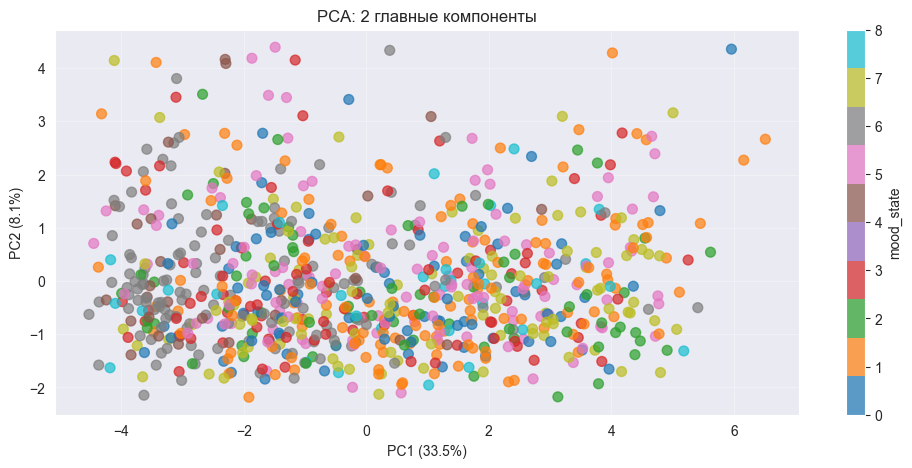

In [6]:
# pca для визуализации
pca = PCA()
X_train_pca = pca.fit_transform(X_train_processed)

print("Дисперсия по главным компонентам:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.3f} ({pca.explained_variance_ratio_[i]*100:.1f}%)")

print(f"\nОбщая объясненная дисперсия топ-2 PC: {pca.explained_variance_ratio_[:2].sum():.3f}")
print(f"Общая объясненная дисперсия топ-5 PC: {pca.explained_variance_ratio_[:5].sum():.3f}")

plt.figure(figsize=(12, 5))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                      c=y_train, cmap='tab10', alpha=0.7, s=50)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA: 2 главные компоненты')
plt.colorbar(scatter, label='mood_state')
plt.grid(True, alpha=0.3)
plt.show()


# Случайный лес

Accuracy на train: 0.713
Accuracy на test:  0.230

Метрики по классам
              precision    recall  f1-score   support

       Angry       0.07      0.10      0.08        20
     Anxious       0.24      0.24      0.24        34
   Depressed       0.00      0.00      0.00        18
    Euphoric       0.19      0.14      0.16        21
     Excited       0.29      0.62      0.40         8
   Irritable       0.32      0.27      0.29        30
      Normal       0.50      0.47      0.48        34
    Restless       0.04      0.04      0.04        27
   Withdrawn       0.18      0.38      0.24         8

    accuracy                           0.23       200
   macro avg       0.20      0.25      0.22       200
weighted avg       0.23      0.23      0.22       200



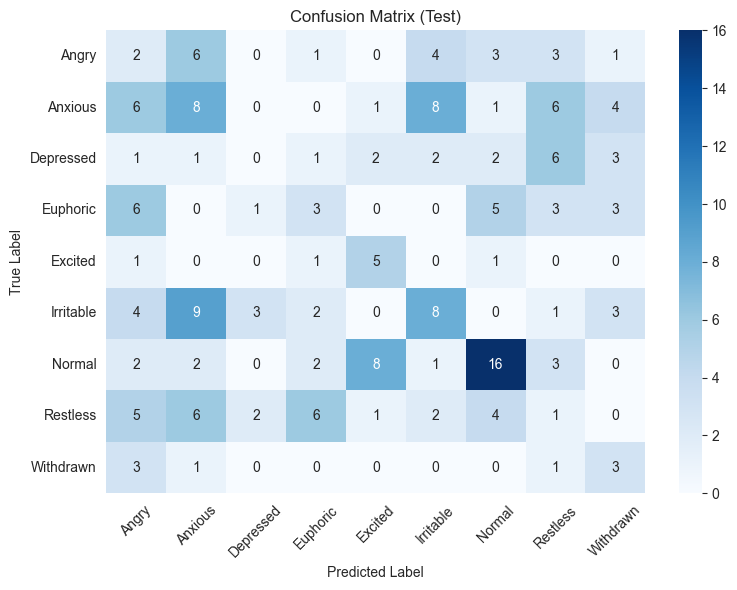


Самые важные признаки
daily_gaming_hours             0.106
sleep_hours                    0.101
face_to_face_social_hours_weekly 0.094
monthly_game_spending_usd      0.078
exercise_hours_weekly          0.062
weight_change_kg               0.054
social_isolation_score         0.051
age                            0.046
years_gaming                   0.045
eye_strain                     0.017


In [11]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=6,
                            min_samples_split=10,
                            min_samples_leaf=5,
                            class_weight='balanced',
                            random_state=42)
rf.fit(X_train_processed, y_train)

y_pred_train = rf.predict(X_train_processed)
y_pred_test = rf.predict(X_test_processed)

print(f"Accuracy на train: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy на test:  {accuracy_score(y_test, y_pred_test):.3f}")
print()

print("Метрики по классам")
target_names = le_target.classes_
print(classification_report(y_test, y_pred_test, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Test)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# самые важные признаки
feature_names = (numeric_cols +
                 list(preprocessor.named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-10:]

print("\nСамые важные признаки")
for i in top_idx[::-1]:
    print(f"{feature_names[i]:30} {importances[i]:.3f}")

группировка состояний для уменьшения количества классов

Новые классы:
mood_state_grouped
Other        187
Normal       172
Anxious      169
Irritable    147
Restless     135
Angry        102
Depressed     88
Name: count, dtype: int64

Новые размеры: train (800, 69), test (200, 69)
Accuracy train: 0.868
Accuracy test:  0.785

Метрики по классам
              precision    recall  f1-score   support

       Angry       1.00      1.00      1.00        20
     Anxious       1.00      1.00      1.00        34
   Depressed       0.95      1.00      0.97        18
   Irritable       0.57      0.93      0.71        29
      Normal       0.65      0.63      0.64        35
       Other       1.00      0.35      0.52        37
    Restless       0.70      0.85      0.77        27

    accuracy                           0.79       200
   macro avg       0.84      0.82      0.80       200
weighted avg       0.83      0.79      0.77       200



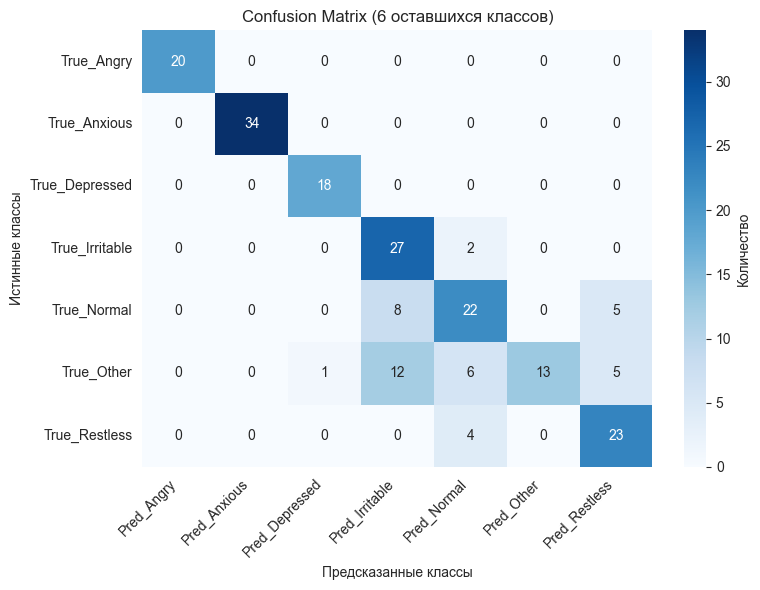


Самые важные признаки
daily_gaming_hours             0.106
sleep_hours                    0.101
face_to_face_social_hours_weekly 0.094
monthly_game_spending_usd      0.078
exercise_hours_weekly          0.062
weight_change_kg               0.054
social_isolation_score         0.051
age                            0.046
years_gaming                   0.045
eye_strain                     0.017


In [15]:
rare_states = ['Excited', 'Withdrawn', 'Euphoric']
df['mood_state_grouped'] = df['mood_state'].replace(
    {state: 'Other' for state in rare_states}
)

print("Новые классы:")
print(df['mood_state_grouped'].value_counts())
print()

le_target = LabelEncoder()
df['mood_state_grouped_encoded'] = le_target.fit_transform(df['mood_state_grouped'])
y = df['mood_state_grouped_encoded']
X = df.drop(['mood_state', 'mood_state_grouped', 'mood_state_grouped_encoded'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Новые размеры: train {X_train_processed.shape}, test {X_test_processed.shape}")

rf_improved = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,           # Ограничение глубины
    min_samples_split=10,
    min_samples_leaf=5,    # Минимум сэмплов в листе
    class_weight='balanced',
    random_state=42
)

rf_improved.fit(X_train_processed, y_train)

# 7. Результаты
y_pred_test = rf_improved.predict(X_test_processed)
print(f"Accuracy train: {accuracy_score(y_train, rf_improved.predict(X_train_processed)):.3f}")
print(f"Accuracy test:  {accuracy_score(y_test, y_pred_test):.3f}")
print()

print("Метрики по классам")
print(classification_report(y_test, y_pred_test,
                            target_names=le_target.classes_,
                            zero_division=0))

cm = confusion_matrix(y_test, y_pred_test)
active_classes = le_target.classes_
cm_df = pd.DataFrame(cm,
                     index=[f"True_{c}" for c in active_classes],
                     columns=[f"Pred_{c}" for c in active_classes])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Количество'})
plt.title('Confusion Matrix (6 оставшихся классов)')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# самые важные признаки
feature_names = (numeric_cols +
                 list(preprocessor.named_transformers_['cat']
                      .get_feature_names_out(categorical_cols)))
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-10:]

print("\nСамые важные признаки")
for i in top_idx[::-1]:
    print(f"{feature_names[i]:30} {importances[i]:.3f}")